**Student Name:** Durjoy  
**Student ID:** 23-50576-1  
**Course:** CSC 4262 Programming in Python — Section A  
**Instructor:** MD. Tanzeem Rahat  

**Dataset:** NYC Airbnb Open Data (2019)  
**Original Source:** [Kaggle Link](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

# NYC Airbnb 2019 — Exploratory Data Analysis (EDA)

**Dataset:** AB_NYC_2019.csv (Airbnb NYC listings)  
**Goal:** Explore price patterns using subgroup comparisons, relationship analysis, and outlier/anomaly detection.

## Research Questions (RQs)

1. **RQ1 (Subgroup comparison):** How does price vary across neighbourhood groups (boroughs) and room types?
2. **RQ2 (Relationship):** Is there a relationship between listing price (log-transformed) and the number of reviews?
3. **RQ3 (Outlier/Anomaly):** How many price outliers exist, and which boroughs/room types have the highest outlier concentration?

**Why these questions matter:**
- **RQ1:** Borough and room type are practical factors that directly affect what a guest pays, so comparing them helps explain price differences.
- **RQ2:** Many people assume more reviews means higher price; correlation helps test whether that assumption is true in this dataset.
- **RQ3:** Outliers can distort summary statistics, and checking where they concentrate helps identify premium/luxury segments.

## Load Dataset

The dataset is loaded from a public GitHub raw link to ensure the notebook is fully reproducible when rerun.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/roydurjoy412/Programming_In_Python_FinalTerm/main/data/AB_NYC_2019.csv"
df = pd.read_csv(url)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Quick Overview

In this section, I check the dataset shape, missing values, and duplicates to understand overall data quality before cleaning.

In [2]:
df.shape

(48895, 16)

In [3]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [4]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [5]:
df.sample(5, random_state=42)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
44383,34205267,"Spacious, sunny room in Queens/Brooklyn",913940,Giancarlo,Queens,Ridgewood,40.70666,-73.90779,Private room,30,21,0,NaN,NaN,1,73
15394,12342297,Private bedroom in high-ceiling 4BR apartment!,19953913,Alejandro,Manhattan,Hell's Kitchen,40.76116,-73.99016,Private room,120,2,17,2017-04-28,0.43,1,0
43230,33527778,Sonder | Stock Exchange | Stunning 3BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70763,-74.01050,Entire home/apt,470,2,5,2019-06-02,1.88,327,272
16332,13136376,Spacious 2 Bedroom with Balcony,16110448,Gingie,Manhattan,East Harlem,40.79658,-73.93287,Entire home/apt,199,2,30,2019-06-03,0.80,1,30


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(15)

,missing,missing_%
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


In [8]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

I applied the following cleaning steps:

- Converted `last_review` into datetime format. Invalid values were safely converted to missing (NaT).
- Filled missing values in `reviews_per_month` with 0. This keeps rows in the dataset and avoids NaN issues during analysis (interpreted as no recorded monthly review activity).
- Filled missing `host_name` and `name` values with `"Unknown"` since the missing count is very small.
- Removed rows with `price <= 0` because non-positive prices are not realistic for listings.

After cleaning, I rechecked missing values and duplicates to confirm the changes.

In [9]:
# Step 4.1: Baseline checks (before cleaning)
print("Shape:", df.shape)

missing_before = df.isna().sum().sort_values(ascending=False)
missing_pct_before = (missing_before / len(df) * 100).round(2)

baseline = pd.DataFrame({
    "missing_before": missing_before,
    "missing_%_before": missing_pct_before
})

print("\nTop missing columns (before):")
display(baseline[baseline["missing_before"] > 0])
print("\nDuplicates (before):", df.duplicated().sum())

Shape: (48895, 16)

Top missing columns (before):


,missing_before,missing_%_before
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03



Duplicates (before): 0


In [10]:
# Step 4.2: Cleaning

df_clean = df.copy()

# Cleaning step 1: Parse last_review to datetime
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

# Cleaning step 2: reviews_per_month missing -> 0
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

# Cleaning step 3: Fill missing text fields (small %)
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")
df_clean["name"] = df_clean["name"].fillna("Unknown")

df_clean = df_clean[df_clean["price"] > 0].copy()

df_clean.shape

df_clean = df_clean.drop_duplicates()

In [11]:
# Step 4.3: After-cleaning checks

missing_after = df_clean.isna().sum().sort_values(ascending=False)
missing_pct_after = (missing_after / len(df_clean) * 100).round(2)

after_tbl = pd.DataFrame({
    "missing_after": missing_after,
    "missing_%_after": missing_pct_after
})

print("Shape after cleaning:", df_clean.shape)
print("Duplicates after cleaning:", df_clean.duplicated().sum())

print("\nTop missing columns (after):")
display(after_tbl.head(10))

compare = pd.concat([baseline, after_tbl], axis=1)
display(compare.loc[compare["missing_before"] > 0].head(10))

Shape after cleaning: (48884, 16)
Duplicates after cleaning: 0

Top missing columns (after):


,missing_after,missing_%_after
last_review,10051,20.56
id,0,0.00
host_id,0,0.00
name,0,0.00
neighbourhood_group,0,0.00
neighbourhood,0,0.00
latitude,0,0.00
host_name,0,0.00
longitude,0,0.00
room_type,0,0.00


,missing_before,missing_%_before,missing_after,missing_%_after
last_review,10052,20.56,10051,20.56
reviews_per_month,10052,20.56,0,0.00
host_name,21,0.04,0,0.00
name,16,0.03,0,0.00


## Feature Engineering

To support the analysis, I created these derived features:

- `last_review_year`: extracted from `last_review` to enable simple year-based grouping.
- `price_log`: computed as `log(1 + price)` to reduce strong skew in prices and make plots/correlations easier to interpret.
- `is_high_price_p95`: a binary flag for listings priced at or above the 95th percentile (top 5%) to identify high-price listings.

In [12]:
# Step 5.1: Feature Engineering

df_fe = df_clean.copy()

# Feature 1: last_review_year
df_fe["last_review_year"] = df_fe["last_review"].dt.year

# Feature 2: price_log
df_fe["price_log"] = np.log1p(df_fe["price"])

# Feature 3 : high_price flag
p95 = np.percentile(df_fe["price"], 95)
df_fe["is_high_price_p95"] = (df_fe["price"] >= p95).astype(int)
print("P95 price threshold:", p95)
df_fe[["price", "price_log", "last_review", "last_review_year", "is_high_price_p95"]].head()

P95 price threshold: 355.0


,price,price_log,last_review,last_review_year,is_high_price_p95
0,149,5.010635,2018-10-19,2018.0,0
1,225,5.420535,2019-05-21,2019.0,0
2,150,5.017280,NaT,NaN,0
3,89,4.499810,2019-07-05,2019.0,0
4,80,4.394449,2018-11-19,2018.0,0


In [13]:
# Step 5.2: Verify engineered features

df_fe[["last_review_year", "price_log", "is_high_price_p95"]].describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
last_review_year,38833.0,2018.287642,1.181258,2011.000000,2018.000000,2019.000000,2019.000000,2019.00000
price_log,48884.0,4.737951,0.691782,2.397895,4.248495,4.672829,5.170484,9.21044
is_high_price_p95,48884.0,0.050139,0.218234,0.000000,0.000000,0.000000,0.000000,1.00000


In [14]:
# last_review_year: year-wise median price
df_fe.groupby("last_review_year")["price"].median().dropna().sort_index()

,price
last_review_year,
2011.0,140.0
2012.0,125.0
2013.0,150.0
2014.0,140.0
2015.0,110.0
2016.0,105.0
2017.0,100.0
2018.0,100.0
2019.0,105.0


In [15]:
# is_high_price_p95: high-price (top 5%) rate by borough
(df_fe.groupby("neighbourhood_group")["is_high_price_p95"].mean() * 100).sort_values(ascending=False).round(2)

,is_high_price_p95
neighbourhood_group,
Manhattan,8.31
Brooklyn,2.71
Staten Island,2.14
Bronx,1.65
Queens,1.41


Note: The year-wise summary is limited because many listings have missing `last_review` values.

## Analysis (Tables & Statistics)

This section includes:
- Subgroup comparisons of price by borough and room type
- A two-way comparison (borough × room type) using a pivot table
- Relationship analysis between `price_log` and `number_of_reviews`
- Outlier/anomaly detection using NumPy-based computations (percentile and z-score)

In [16]:
# Step 6.1: Subgroup comparison 1 (borough-level price)

price_by_borough = (df_fe
    .groupby("neighbourhood_group")["price"]
    .agg(count="size", mean="mean", median="median", p75=lambda s: np.percentile(s, 75))
    .sort_values("median", ascending=False)
)

display(price_by_borough)

,count,mean,median,p75
neighbourhood_group,,,,
Manhattan,21660,196.884903,150.0,220.0
Brooklyn,20095,124.438915,90.0,150.0
Queens,5666,99.517649,75.0,110.0
Staten Island,373,114.812332,75.0,110.0
Bronx,1090,87.577064,65.0,99.0


In [17]:
# Step 6.2: Subgroup comparison 2 (room type-level price)

price_by_room = (df_fe
    .groupby("room_type")["price"]
    .agg(count="size", mean="mean", median="median", p75=lambda s: np.percentile(s, 75))
    .sort_values("median", ascending=False)
)

display(price_by_room)

,count,mean,median,p75
room_type,,,,
Entire home/apt,25407,211.810918,160.0,229.0
Private room,22319,89.809131,70.0,95.0
Shared room,1158,70.248705,45.0,75.0


In [18]:
# Step 6.3: Two-way comparison (borough x room_type)

pivot_median = pd.pivot_table(
    df_fe,
    index="neighbourhood_group",
    columns="room_type",
    values="price",
    aggfunc="median"
).round(2)

display(pivot_median)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,54.0,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


In [19]:
# Step 6.4: Relationship analysis with P-value
from scipy import stats

corr_spearman, p_value = stats.spearmanr(df_fe["price_log"], df_fe["number_of_reviews"])
corr_pearson = df_fe[["price_log", "number_of_reviews"]].corr(method="pearson").iloc[0, 1]

print("Spearman corr(price_log, number_of_reviews):", round(corr_spearman, 4))
print("Pearson  corr(price_log, number_of_reviews):", round(corr_pearson, 4))
print(f"P-value (Spearman): {p_value:.6f}")
print("Interpretation: Statistically significant due to large sample size, but practically meaningless (|r| < 0.1).")

Spearman corr(price_log, number_of_reviews): -0.0549
Pearson  corr(price_log, number_of_reviews): -0.0426
P-value (Spearman): 0.000000
Interpretation: Statistically significant due to large sample size, but practically meaningless (|r| < 0.1).


In [20]:
# Step 6.5: Relationship by subgroup (room_type-wise)

rows = []
for rt, g in df_fe.groupby("room_type"):
    corr = g[["price_log", "number_of_reviews"]].corr(method="spearman").iloc[0, 1]
    rows.append((rt, corr))

corr_by_room = (
    pd.DataFrame(rows, columns=["room_type", "spearman_corr_priceLog_reviews"])
      .set_index("room_type")
      .sort_values("spearman_corr_priceLog_reviews")
)

display(corr_by_room)

,spearman_corr_priceLog_reviews
room_type,
Entire home/apt,-0.131356
Shared room,-0.058210
Private room,-0.007403


## NumPy-Based Computation & Outlier Detection

I used NumPy for two custom computations:

1. **95th percentile (P95) threshold:** This identifies high-price listings (top 5%).
2. **Z-score outliers on log-price:** Because price is highly skewed, I detect outliers on `price_log`. Listings with `|z| ≥ 3` are treated as outliers.

I also compare outlier rates across boroughs and room types to see where extreme prices are concentrated.

In [21]:
# Step 7:NumPy-Based Custom Computation & Outlier/Anomaly Analysis

# 1. NumPy Percentile (high-price threshold P95)
p95 = np.percentile(df_fe["price"].to_numpy(), 95)
high_price_count = int((df_fe["price"] >= p95).sum())
high_price_pct = high_price_count / len(df_fe) * 100

print(f"P95 threshold (price): ${p95:.2f}")
print(f"High-price listings (>=P95): {high_price_count} ({high_price_pct:.2f}%)\n")

# 2. NumPy Z-score on log-price (Anomaly Detection)
x = df_fe["price_log"].to_numpy()
z = (x - x.mean()) / x.std(ddof=0)

df_fe["price_log_z"] = z
df_fe["is_outlier_z3"] = (np.abs(df_fe["price_log_z"]) >= 3).astype(int)

outlier_count = int(df_fe["is_outlier_z3"].sum())
outlier_pct = outlier_count / len(df_fe) * 100

print(f"Outliers (|z| >= 3 on price_log): {outlier_count} ({outlier_pct:.2f}%)\n")

# 3. outliers concentrated? (By Borough)
print("--- Outlier Rate by Borough ---")
outlier_by_borough = df_fe.groupby("neighbourhood_group")["is_outlier_z3"].agg(["sum", "count"])
outlier_by_borough["outlier_rate_%"] = (outlier_by_borough["sum"] / outlier_by_borough["count"] * 100).round(2)
outlier_by_borough = outlier_by_borough.sort_values("outlier_rate_%", ascending=False)
display(outlier_by_borough)

# 4. outliers concentrated? (By Room Type)
print("\n--- Outlier Rate by Room Type ---")
outlier_by_room = df_fe.groupby("room_type")["is_outlier_z3"].agg(["sum", "count"])
outlier_by_room["outlier_rate_%"] = (outlier_by_room["sum"] / outlier_by_room["count"] * 100).round(2)
outlier_by_room = outlier_by_room.sort_values("outlier_rate_%", ascending=False)
display(outlier_by_room)

# 5. Sensitivity Analysis (Mean price with vs without outliers)
print("\n--- Sensitivity Analysis ---")
print(f"Mean price WITH outliers: ${df_fe['price'].mean():.2f}")
mean_without_outliers = df_fe[~df_fe['is_outlier_z3'].astype(bool)]['price'].mean()
print(f"Mean price WITHOUT outliers: ${mean_without_outliers:.2f}")

P95 threshold (price): $355.00
High-price listings (>=P95): 2451 (5.01%)

Outliers (|z| >= 3 on price_log): 378 (0.77%)

--- Outlier Rate by Borough ---


,sum,count,outlier_rate_%
neighbourhood_group,,,
Manhattan,266,21660,1.23
Staten Island,4,373,1.07
Brooklyn,87,20095,0.43
Queens,18,5666,0.32
Bronx,3,1090,0.28



--- Outlier Rate by Room Type ---


,sum,count,outlier_rate_%
room_type,,,
Entire home/apt,289,25407,1.14
Shared room,9,1158,0.78
Private room,80,22319,0.36



--- Sensitivity Analysis ---
Mean price WITH outliers: $152.76
Mean price WITHOUT outliers: $139.39


## Visualizations (Matplotlib)

Below are four Matplotlib charts. After each plot, I include a short interpretation (2–3 sentences).

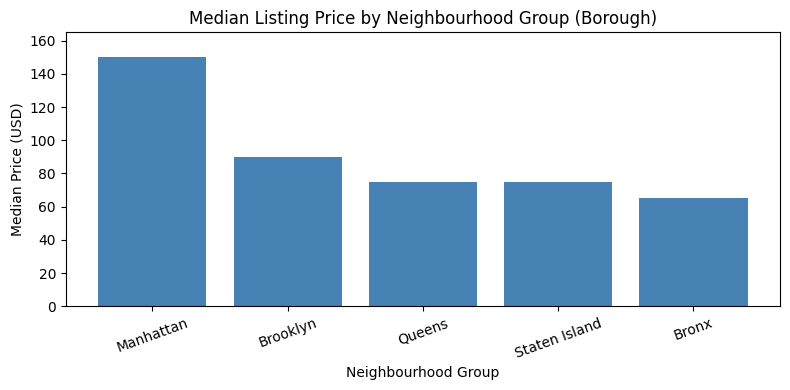

In [22]:
# Plot 1: Median price by borough

borough_median = df_fe.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(borough_median.index, borough_median.values, color="steelblue")
plt.title("Median Listing Price by Neighbourhood Group (Borough)")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Median Price (USD)")
plt.xticks(rotation=20)
plt.ylim(0, borough_median.max() * 1.10)
plt.tight_layout()
plt.savefig("plot_1.png", dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Plot 1):** Manhattan has the highest median listing price, while the Bronx has the lowest. This indicates that location (borough) has a strong effect on typical Airbnb prices in NYC.

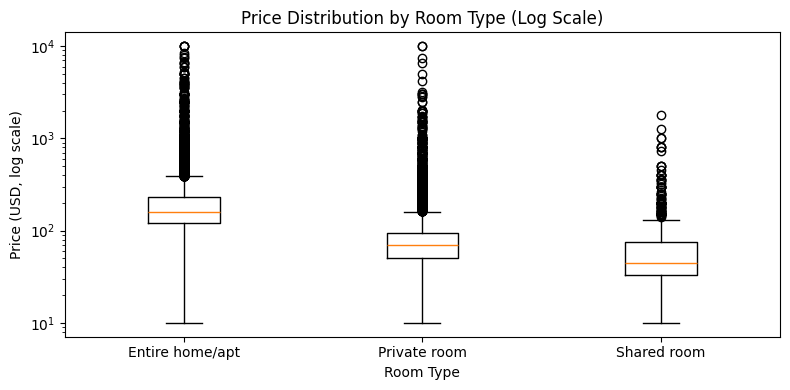

In [23]:
# Plot 2: Boxplot of price by room type

room_order = ["Entire home/apt", "Private room", "Shared room"]
data = [df_fe.loc[df_fe["room_type"] == rt, "price"].values for rt in room_order]

fig, ax = plt.subplots(figsize=(8,4))
ax.boxplot(data, showfliers=True)

ax.set_xticks(range(1, len(room_order) + 1))
ax.set_xticklabels(room_order)

ax.set_yscale("log")
ax.set_title("Price Distribution by Room Type (Log Scale)")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price (USD, log scale)")
fig.tight_layout()
fig.savefig("plot_2.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation (Plot 2):** Entire home/apartment listings have the highest median price and the widest spread. Using a log scale makes the distributions easier to compare even with extreme high-price outliers.

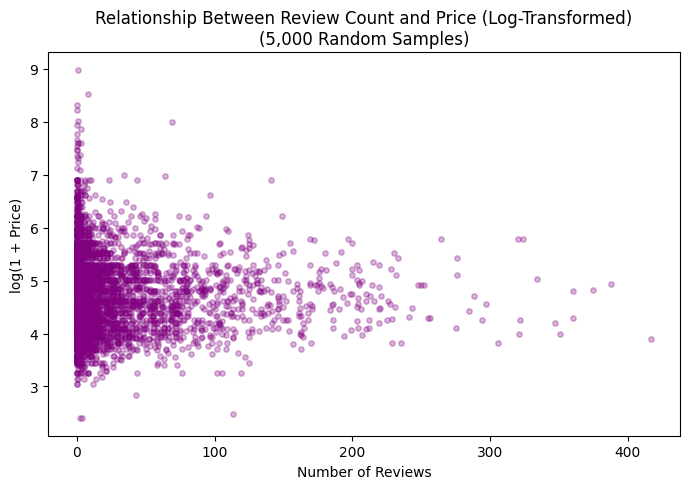

In [24]:
# Plot 3: Scatter plot
plt.figure(figsize=(7,5))

sample_df = df_fe.sample(5000, random_state=42)

plt.scatter(sample_df["number_of_reviews"], sample_df["price_log"], alpha=0.3, s=15, color="purple")
plt.title("Relationship Between Review Count and Price (Log-Transformed)\n(5,000 Random Samples)")
plt.xlabel("Number of Reviews")
plt.ylabel("log(1 + Price)")
plt.tight_layout()
plt.savefig("plot_3.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation (Plot 3):** The relationship between review count and log-price is very weak (correlation close to 0). This suggests that the number of reviews alone does not explain pricing well.

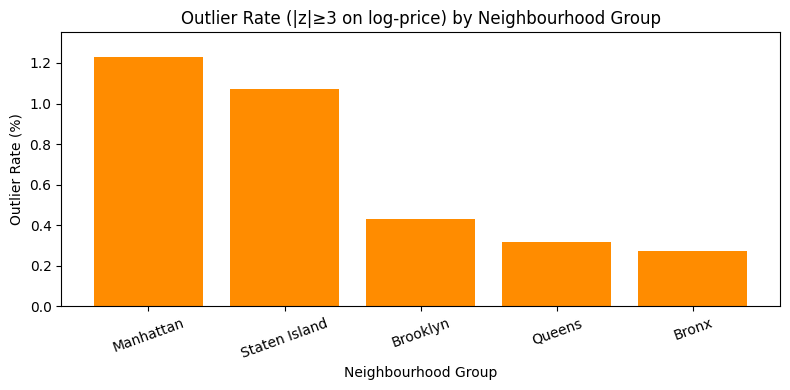

In [25]:
# Plot 4: Outlier rate by borough

outlier_rate = (df_fe.groupby("neighbourhood_group")["is_outlier_z3"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(outlier_rate.index, outlier_rate.values, color="darkorange")
plt.title("Outlier Rate (|z|≥3 on log-price) by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Outlier Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, outlier_rate.max() * 1.10)
plt.tight_layout()
plt.savefig("plot_4.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation (Plot 4):** Outlier rates are highest in Manhattan, indicating that extreme/luxury pricing is more concentrated there than in other boroughs.

## Step 9 — Key Findings (Summary)

1. **Borough differences are large:** Manhattan has the highest median price (\$150), while the Bronx has the lowest (\$65), showing a clear location-based price gap.
2. **Room type strongly affects price:** Entire home/apt listings have a median price of \$160, compared to \$70 for private rooms and \$45 for shared rooms.
3. **Most expensive segment:** In the borough × room type comparison, **Entire home/apt in Manhattan** has the highest median price (about \$191 in the pivot table).
4. **Weak relationship with reviews:** The Spearman correlation between `price_log` and `number_of_reviews` is very weak (overall **-0.0549**). By room type, the strongest negative value appears for Entire home/apt (about **-0.131**), but it is still not strong enough to treat reviews as a price predictor.
5. **Outliers are rare but concentrated:** High-price listings (≥ P95) use a threshold of **\$355**, covering **2451 listings (5.01%)**. Z-score outliers on log-price are **378 listings (0.77%)**, and the highest outlier concentration is in Manhattan (**1.23%**) and Entire home/apt (**1.14%**).

## Conclusion

Overall, Airbnb prices in NYC are mainly driven by location (borough) and room type. Review count shows only a weak relationship with price. Price outliers exist but represent a small share of the dataset, and they are concentrated in specific market segments.

## Limitations

- The `last_review` column contains many missing values, so time-based patterns should be interpreted cautiously.
- This dataset is a snapshot of NYC listings in **2019**, so results may not generalize to other years or cities.
- Prices are host-provided listing prices; the dataset does not confirm the final transaction price.
- The dataset has no occupancy or revenue information, so price does not equal earnings.
- Correlation results do not prove causation; other unmeasured factors may influence both reviews and price.